In [59]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [63]:
df = pd.read_csv("gurgaon_properties_missing_value_imputation.csv")

In [22]:
df.head(5)

,property_type,society,sector,price,price_per_sqft,bedRoom,bathroom,balcony,floorNum,agePossession,built_up_area,study room,servant room,store room,pooja room,others,furnishing_type,luxury_score
0,flat,signature global park 4,sector 36,0.82,7586.0,3,2,2,2.0,New Property,850.0,0,0,0,0,0,0,8
1,flat,smart world gems,sector 89,0.95,8597.0,2,2,2,4.0,New Property,1226.0,1,1,0,0,0,0,38
2,flat,breez global hill view,sohna road,0.32,5470.0,2,2,1,17.0,New Property,1000.0,0,0,0,0,0,0,49
3,flat,bestech park view sanskruti,sector 92,1.60,8020.0,3,4,3+,10.0,Relatively New,1615.0,0,1,0,0,1,1,174
4,flat,suncity avenue,sector 102,0.48,9023.0,2,2,1,5.0,Relatively New,582.0,0,0,1,0,0,0,159


In [23]:
latlong = pd.read_csv("gurgaon_sectors_geo.csv")

In [24]:
latlong['sector'] = latlong['sector'].str.replace(r',.*$', '', regex=True)

In [25]:
latlong

,sector,south_lat,north_lat,west_lon,east_lon,geojson
0,sector 1,28.348582,28.371660,76.940097,76.959219,"{'type': 'Polygon', 'coordinates': [[[76.94009..."
1,sector 2,28.502112,28.514894,77.024672,77.041792,"{'type': 'Polygon', 'coordinates': [[[77.02467..."
2,sector 3,28.480736,28.505007,77.010926,77.028783,"{'type': 'Polygon', 'coordinates': [[[77.01092..."
3,sector 4,28.468834,28.480736,77.001979,77.017922,"{'type': 'Polygon', 'coordinates': [[[77.00197..."
4,sector 5,28.364787,28.372240,76.919419,76.934045,"{'type': 'Polygon', 'coordinates': [[[76.91941..."
...,...,...,...,...,...,...
126,sector 115,28.528942,28.540905,77.001336,77.013261,"{'type': 'Polygon', 'coordinates': [[[77.00133..."
127,gwal pahari,28.427598,28.437674,77.141618,77.155425,"{'type': 'Polygon', 'coordinates': [[[77.14161..."
128,manesar,28.234414,28.415503,76.782486,77.016274,"{'type': 'Polygon', 'coordinates': [[[76.78248..."
129,sohna road,28.381794,28.385461,77.052674,77.054044,"{'type': 'LineString', 'coordinates': [[77.052..."


In [26]:
new_df = df.merge(latlong, on='sector')

In [30]:
new_df

,property_type,society,sector,price,price_per_sqft,bedRoom,bathroom,balcony,floorNum,agePossession,...,store room,pooja room,others,furnishing_type,luxury_score,south_lat,north_lat,west_lon,east_lon,geojson
0,flat,signature global park 4,sector 36,0.82,7586.0,3,2,2,2.0,New Property,...,0,0,0,0,8,28.410702,28.430322,76.979014,77.000367,"{'type': 'Polygon', 'coordinates': [[[76.97901..."
1,flat,avl 36 gurgaon,sector 36,0.75,7500.0,2,2,2,5.0,Relatively New,...,0,0,0,0,26,28.410702,28.430322,76.979014,77.000367,"{'type': 'Polygon', 'coordinates': [[[76.97901..."
2,flat,signature global park 4,sector 36,1.00,9901.0,3,2,3,2.0,New Property,...,0,0,0,0,128,28.410702,28.430322,76.979014,77.000367,"{'type': 'Polygon', 'coordinates': [[[76.97901..."
3,flat,krisumi waterfall residences,sector 36,4.10,15501.0,3,4,3,30.0,New Property,...,0,0,0,2,49,28.410702,28.430322,76.979014,77.000367,"{'type': 'Polygon', 'coordinates': [[[76.97901..."
4,flat,signature global park 4,sector 36,0.72,6660.0,3,2,3,3.0,Under Construction,...,0,0,0,0,0,28.410702,28.430322,76.979014,77.000367,"{'type': 'Polygon', 'coordinates': [[[76.97901..."
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3495,flat,vatika xpressions,sector 88,1.10,8148.0,2,4,3+,2.0,Under Construction,...,0,0,0,0,58,28.412018,28.429989,76.949856,76.964123,"{'type': 'Polygon', 'coordinates': [[[76.94985..."
3496,flat,vatika xpressions,sector 88,0.92,7360.0,2,2,2,3.0,Relatively New,...,0,1,0,0,174,28.412018,28.429989,76.949856,76.964123,"{'type': 'Polygon', 'coordinates': [[[76.94985..."
3497,flat,vatika xpressions,sector 88,0.92,6815.0,2,2,3,3.0,New Property,...,0,0,0,0,26,28.412018,28.429989,76.949856,76.964123,"{'type': 'Polygon', 'coordinates': [[[76.94985..."
3498,house,independent,sector 27,4.25,31481.0,5,5,3+,3.0,Relatively New,...,0,1,0,1,49,28.444657,28.484657,77.063951,77.103950,"{'type': 'Point', 'coordinates': [77.0839505, ..."


In [33]:
group_df = (
    new_df
    .groupby('sector')[['price', 'price_per_sqft', 'built_up_area', 'south_lat', 'north_lat', 'west_lon', 'east_lon']]
    .mean()
    .reset_index()
)

# If you want to keep geojson (e.g., first occurrence per sector)
geojson_df = new_df.groupby('sector')['geojson'].first().reset_index()
group_df = group_df.merge(geojson_df, on='sector', how='left')


In [34]:
group_df

,sector,price,price_per_sqft,built_up_area,south_lat,north_lat,west_lon,east_lon,geojson
0,dwarka expressway,1.372500,8988.375000,1606.000000,28.466724,28.530647,76.971130,77.034342,"{'type': 'LineString', 'coordinates': [[77.034..."
1,gwal pahari,3.192222,9585.777778,3056.166667,28.427598,28.437674,77.141618,77.155425,"{'type': 'Polygon', 'coordinates': [[[77.14161..."
2,manesar,0.962258,4608.064516,2027.367742,28.234414,28.415503,76.782486,77.016274,"{'type': 'Polygon', 'coordinates': [[[76.78248..."
3,sector 1,1.860000,8249.833333,2327.833333,28.348582,28.371660,76.940097,76.959219,"{'type': 'Polygon', 'coordinates': [[[76.94009..."
4,sector 10,2.092857,11866.571429,1908.857143,28.435881,28.450932,76.997229,77.017508,"{'type': 'Polygon', 'coordinates': [[[76.99722..."
...,...,...,...,...,...,...,...,...,...
98,sector 92,0.934000,5928.290000,1571.341800,28.401223,28.418122,76.899392,76.927685,"{'type': 'Polygon', 'coordinates': [[[76.89939..."
99,sector 93,0.848889,8009.888889,1017.000000,28.408423,28.420795,76.924128,76.941678,"{'type': 'Polygon', 'coordinates': [[[76.92412..."
100,sector 95,0.480545,5602.509091,995.981818,28.394944,28.434944,76.891489,76.931489,"{'type': 'Point', 'coordinates': [76.9114892, ..."
101,sector 99,1.008095,6412.166667,1364.214286,28.444555,28.484555,76.942858,76.982859,"{'type': 'Point', 'coordinates': [76.9628585, ..."


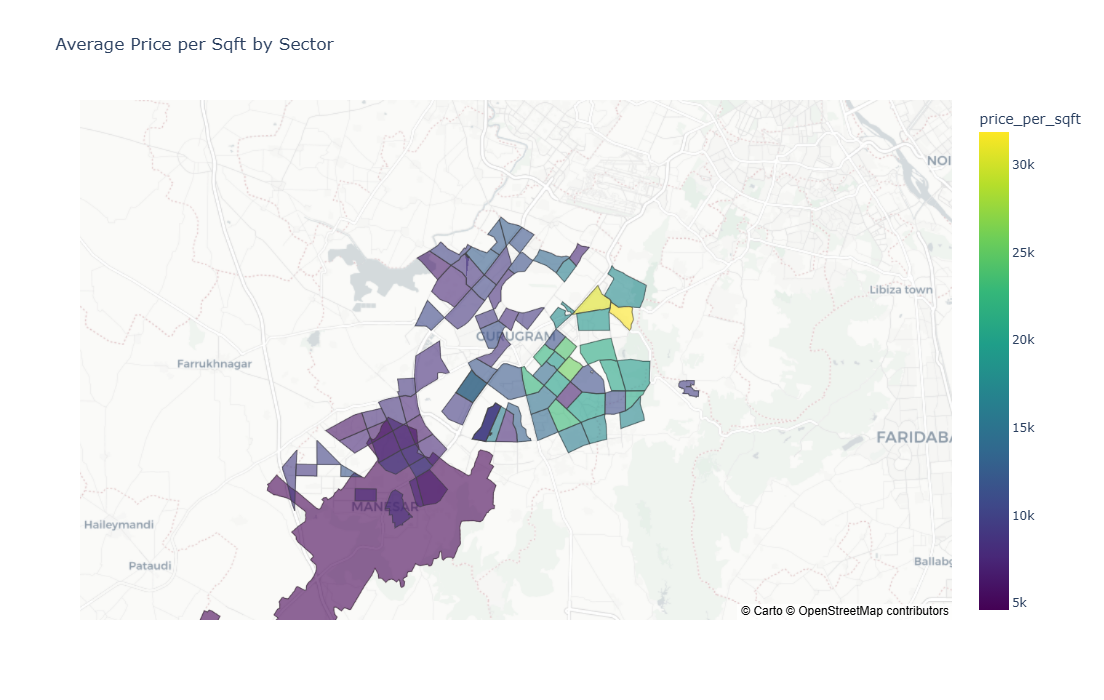

In [46]:
import plotly.express as px
import json
import ast

# --- Safe parsing for geojson column ---
def safe_json_parser(val):
    if isinstance(val, dict):
        return val
    try:
        return json.loads(val)
    except:
        return ast.literal_eval(val)

group_df['geojson'] = group_df['geojson'].apply(safe_json_parser)

# --- Merge all geojsons into one FeatureCollection ---
feature_collection = {
    "type": "FeatureCollection",
    "features": []
}
for _, row in group_df.iterrows():
    gj = row['geojson']

    # If it's not already a Feature, wrap it
    if gj.get("type") != "Feature":
        gj = {
            "type": "Feature",
            "geometry": gj,
            "properties": {"sector": row['sector']}
        }
    else:
        # Ensure sector property exists
        gj["properties"]["sector"] = row['sector']

    feature_collection["features"].append(gj)

# --- Normalize sector values in BOTH places ---
group_df['sector'] = group_df['sector'].astype(str).str.strip().str.lower()
for f in feature_collection['features']:
    f['properties']['sector'] = str(f['properties']['sector']).strip().lower()

# --- Debug: Show unmatched sectors (if any) ---
df_sectors = set(group_df['sector'])
geojson_sectors = {f['properties']['sector'] for f in feature_collection['features']}
# --- Choropleth ---
fig = px.choropleth_mapbox(
    group_df,
    geojson=feature_collection,
    locations='sector',
    color='price_per_sqft',  # Change to 'price' or 'built_up_area' as needed
    featureidkey="properties.sector",
    mapbox_style="carto-positron",
    center={"lat": 28.45, "lon": 77.03},
    zoom=10,
    color_continuous_scale="Viridis",
    opacity=0.6,
    title="Average Price per Sqft by Sector",
    height = 700
)

fig.show()


In [47]:
new_df.to_csv('data_viz1.csv', index = False)

In [4]:
import pandas as pd

df1 = pd.read_csv('gurgaon_properties.csv')

In [5]:
df1.head()

,property_name,property_type,society,price,price_per_sqft,area,areaWithType,bedRoom,bathroom,balcony,additionalRoom,address,floorNum,facing,agePossession,nearbyLocations,description,furnishDetails,features,rating
0,12 Bedroom House for sale in Uppals Southend,house,uppal southend,6.75,31915.0,2115.0,Plot area 235(196.49 sq.m.),12,12,3+,others,"Uppals Southend, Gurgaon, Haryana",3.0,West,5 to 10 Year Old,"['Sri Radhe Krishna Temple', 'Icici bank ATM',...",Address......Uppal southend sector 49 availabl...,NaN,"['Feng Shui / Vaastu Compliant', 'Private Gard...","['Environment5 out of 5', 'Lifestyle5 out of 5..."
1,3 BHK Flat in Sector-33 Sohna,flat,godrej nature plus,1.30,8349.0,1557.0,Super Built up area 1557(144.65 sq.m.),3,2,3+,not available,"Sector-33 Sohna, Gurgaon, Haryana",18.0,North,Within 6 months,"['Signature Global Infinity Mall Sohna', 'Bads...",Bang on nh248 highway. Trusted brand.,NaN,"['Intercom Facility', 'Lift(s)', 'Swimming Poo...",NaN
2,2 BHK Flat in Sector 65 Gurgaon,flat,emaar mgf emerald estate,1.30,20602.0,631.0,Super Built up area 1020(94.76 sq.m.)Carpet ar...,2,2,2,study room,"503, Sector 65 Gurgaon, Gurgaon, Haryana",7.0,West,1 to 5 Year Old,"['Sector 53-54 Metro Station', 'Central Plaza ...",This lovely 2 bhk apartment/flat in sector 65 ...,NaN,"['Private Garden / Terrace', 'Lift(s)', 'Maint...","['Green Area4 out of 5', 'Construction4 out of..."
3,3 BHK Flat in Sector 102 Gurgaon,flat,emaar imperial gardens,2.05,9876.0,2076.0,Carpet area: 2025 (188.13 sq.m.),3,4,3+,servant room,"Sector 102 Gurgaon, Gurgaon, Haryana",14.0,South,1 to 5 Year Old,"['Satya The Hive Mall', 'Gurugram Road', 'Dwar...",Important- Not for brokers. Only serious end u...,NaN,"['Security / Fire Alarm', 'Lift(s)', 'Maintena...","['Green Area5 out of 5', 'Amenities5 out of 5'..."
4,2 BHK Flat in Sector 68 Gurgaon,flat,supertech hues,0.82,6950.0,1180.0,Super Built up area 1180(109.63 sq.m.),2,2,3+,others,"Sector-68 Gurgaon, Sector 68 Gurgaon, Gurgaon,...",21.0,NaN,Under Construction,"['Sri Radhe Krishna Temple', 'Icici bank ATM',...",Residential apartment for sell.The property co...,NaN,"['Intercom Facility', 'Lift(s)', 'Feng Shui / ...","['Environment4 out of 5', 'Safety5 out of 5', ..."


In [9]:
worldcloud_df = df1.merge(df, left_index = True, right_index = True)[['features', 'sector']]

In [10]:
worldcloud_df

,features,sector
0,"['Feng Shui / Vaastu Compliant', 'Private Gard...",sector 36
1,"['Intercom Facility', 'Lift(s)', 'Swimming Poo...",sector 89
2,"['Private Garden / Terrace', 'Lift(s)', 'Maint...",sohna road
3,"['Security / Fire Alarm', 'Lift(s)', 'Maintena...",sector 92
4,"['Intercom Facility', 'Lift(s)', 'Feng Shui / ...",sector 102
...,...,...
3549,"['Power Back-up', 'Intercom Facility', 'Lift(s...",sector 84
3550,"['Feng Shui / Vaastu Compliant', 'Security / F...",sector 109
3551,"['Feng Shui / Vaastu Compliant', 'Security / F...",sector 2
3552,"['Security / Fire Alarm', 'Feng Shui / Vaastu ...",sector 43


In [53]:
import ast

main = []
for item in worldcloud_df['features'].dropna().apply(ast.literal_eval):
    main.extend(item)  # extend instead of append

# main is now a flat 1D list
main

['Feng Shui / Vaastu Compliant',
 'Private Garden / Terrace',
 'Maintenance Staff',
 'Water Storage',
 'Park',
 'Visitor Parking',
 'Waste Disposal',
 'Rain Water Harvesting',
 'Intercom Facility',
 'Lift(s)',
 'Swimming Pool',
 'Park',
 'Shopping Centre',
 'Fitness Centre / GYM',
 'Club house / Community Center',
 'Private Garden / Terrace',
 'Lift(s)',
 'Maintenance Staff',
 'No open drainage around',
 'Bank Attached Property',
 'Piped-gas',
 'Swimming Pool',
 'Park',
 'Natural Light',
 'Airy Rooms',
 'Spacious Interiors',
 'Shopping Centre',
 'Fitness Centre / GYM',
 'Waste Disposal',
 'Rain Water Harvesting',
 'Club house / Community Center',
 'Security / Fire Alarm',
 'Lift(s)',
 'Maintenance Staff',
 'Water Storage',
 'Separate entry for servant room',
 'No open drainage around',
 'Piped-gas',
 'Visitor Parking',
 'Swimming Pool',
 'Park',
 'Security Personnel',
 'Natural Light',
 'Internet/wi-fi connectivity',
 'Airy Rooms',
 'Spacious Interiors',
 'Shopping Centre',
 'Fitness C

In [55]:
from wordcloud import WordCloud

In [56]:
feature_text = ' '.join(main)

In [61]:
import pickle
pickle.dump(feature_text, open('feature_text.pkl', 'wb'))

In [57]:
feature_text

'Feng Shui / Vaastu Compliant Private Garden / Terrace Maintenance Staff Water Storage Park Visitor Parking Waste Disposal Rain Water Harvesting Intercom Facility Lift(s) Swimming Pool Park Shopping Centre Fitness Centre / GYM Club house / Community Center Private Garden / Terrace Lift(s) Maintenance Staff No open drainage around Bank Attached Property Piped-gas Swimming Pool Park Natural Light Airy Rooms Spacious Interiors Shopping Centre Fitness Centre / GYM Waste Disposal Rain Water Harvesting Club house / Community Center Security / Fire Alarm Lift(s) Maintenance Staff Water Storage Separate entry for servant room No open drainage around Piped-gas Visitor Parking Swimming Pool Park Security Personnel Natural Light Internet/wi-fi connectivity Airy Rooms Spacious Interiors Shopping Centre Fitness Centre / GYM Rain Water Harvesting Club house / Community Center Intercom Facility Lift(s) Feng Shui / Vaastu Compliant Piped-gas Security Personnel Maintenance Staff Internet/wi-fi connecti

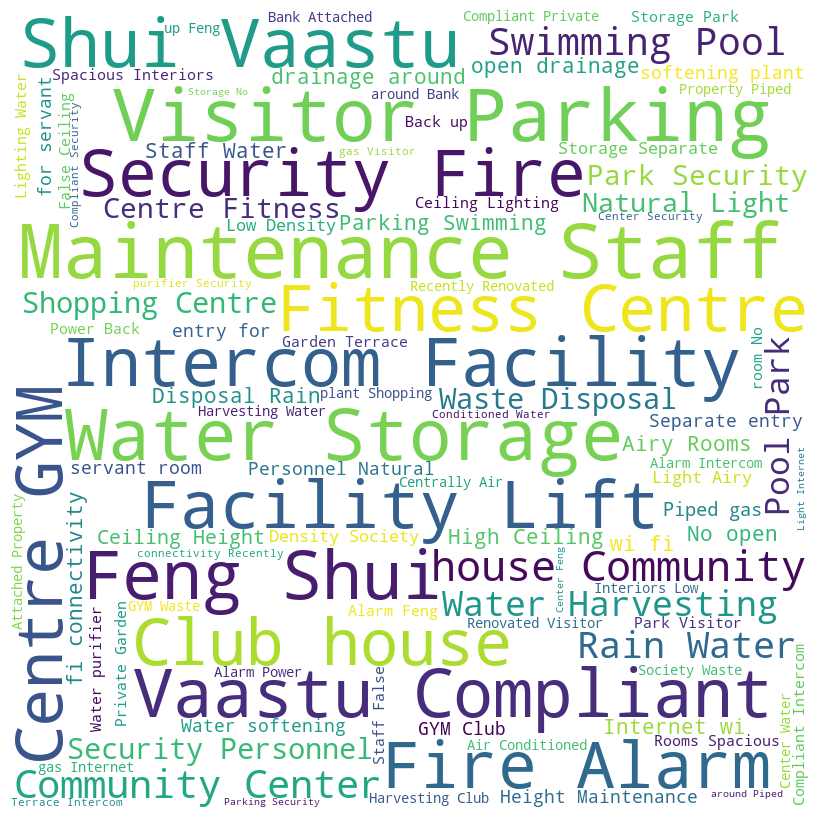

In [60]:
plt.rcParams["font.family"] = "Arial"

wordcloud = WordCloud(width = 800, height = 800,
                     background_color = 'white', 
                     stopwords = set(['s']),
                      min_font_size = 10).generate(feature_text)

plt.figure(figsize = (8,8), facecolor = None)
plt.imshow(wordcloud, interpolation='bilinear')
plt.axis('off')
plt.tight_layout(pad = 0)
plt.show()

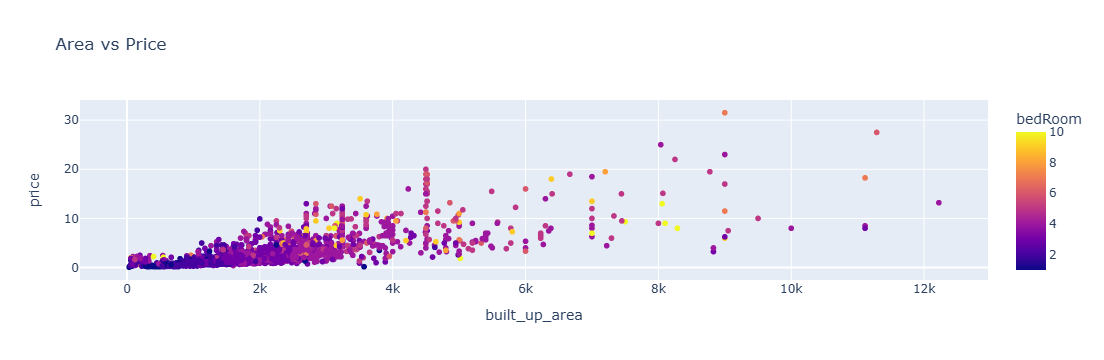

In [64]:
fig = px.scatter(df, x = 'built_up_area', y = 'price', color = 'bedRoom', title = 'Area vs Price')

fig.show()

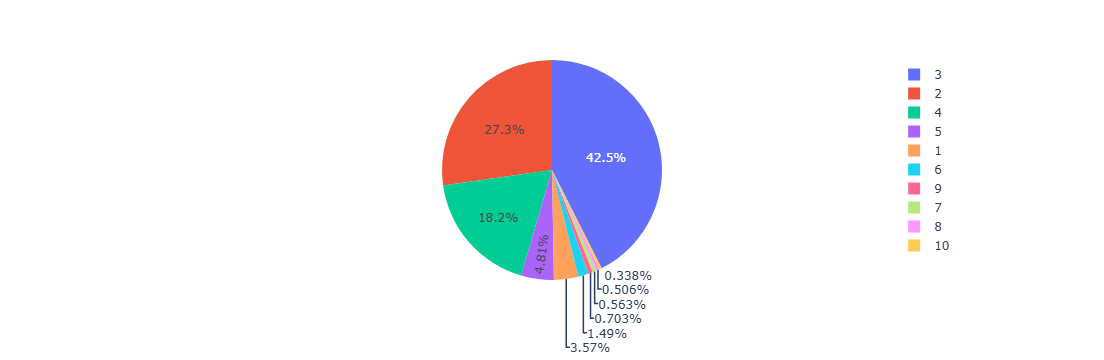

In [65]:
fig = px.pie(df, names = 'bedRoom')
fig.show()

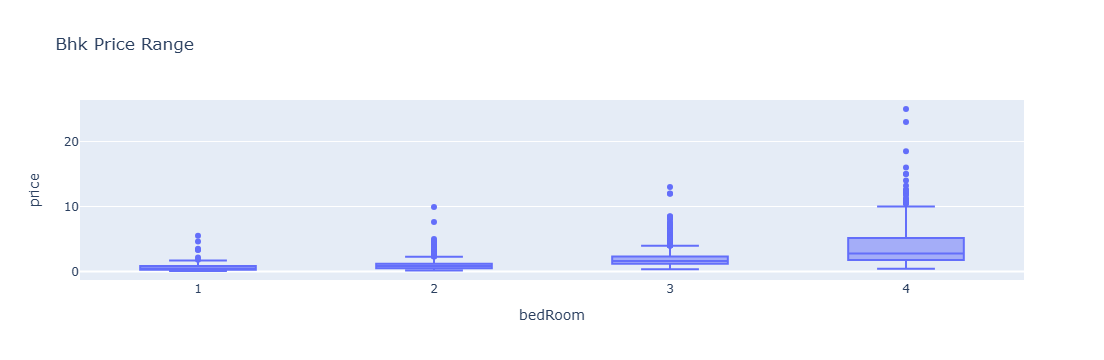

In [66]:
temp_df = df[df['bedRoom'] <= 4]

fig = px.box(temp_df, x = 'bedRoom', y = 'price', title = 'Bhk Price Range')
fig.show()

C:\Users\HP\AppData\Local\Temp\ipykernel_13492\1466444038.py:2: UserWarning:



`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751


F:\Anaconda\Lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning:

use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.

C:\Users\HP\AppData\Local\Temp\ipykernel_13492\1466444038.py:3: UserWarning:



`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to us

<Axes: xlabel='price', ylabel='Density'>

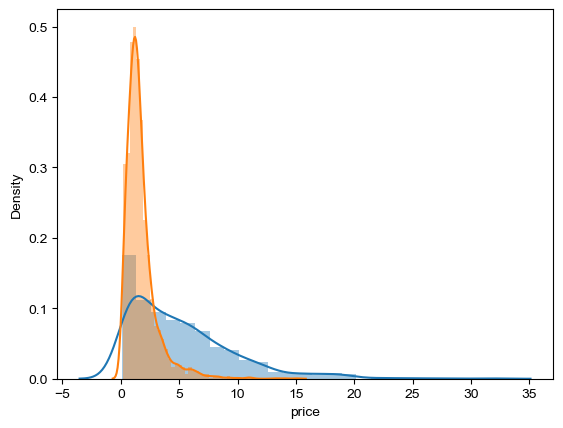

In [71]:
import seaborn as sns
sns.distplot(df[df['property_type'] == 'house']['price'])
sns.distplot(df[df['property_type'] == 'flat']['price'])
